In [1]:
import sys, os
from importlib import reload

import time
import paperPop


# GLOBAL VARIABLES

## Pointers to data and output
OUT_DIR  = 'output/'                                         # general directory for output
FREQ_DIR = os.path.join(OUT_DIR, 'variant_frequencies/')     # directory for experimental variant (codon/aa) frequencies
SEL_DIR  = os.path.join(OUT_DIR, 'selection_coefficients/')  # directory for inferred selection coefficients
DATA_DIR = 'data/'                                           # general directory for external data
RAW_DIR  = os.path.join(DATA_DIR, 'raw_data/')               # unprocessed data directory
FIG_DIR  = 'figures/'                                        # directory for figures

## popDMS parameters
CORR_CUTOFF_PCT = 0.10  # maximum fraction of drop in correlation per log10(gamma) for setting optimal regularization strength
CONST_GAMMA = 0.01

In [2]:
help(popDMS.compute_variant_frequencies)

Help on function compute_variant_frequencies in module popDMS:

compute_variant_frequencies(name, reference_sequence_file, haplotype_counts_file, n_replicates, time_points, time_cols, freq_dir='.', with_epistasis=False, comment_char=None, format='MaveDB')
    Computes variant (allele) frequencies, used by popDMS, from haplotype counts. By
    default, we assume that counts are saved in MaveDB format. For more information
    on this format, see https://www.mavedb.org/docs/mavedb/data_formats.html
    
    Required arguments:
        - name: String that will be associated with saved files, serving as an
            identifier for the data set
        - reference_sequence_file: File path to the reference sequence, which is
            needed to specify 'WT' variants
        - haplotype_counts_file: Path to an existing file recording haplotype
            frequencies
        - n_replicates: Number of experimental replicates
        - time_points: Time points in the data; for normalization

In [3]:
help(popDMS.infer_correlated)

Help on function infer_correlated in module popDMS:

infer_correlated(name, n_replicates, corr_cutoff_pct, gamma=None, norm_WT=False, freq_dir='.', output_dir='.', with_epistasis=False, plot_gamma=True)
    Infer selection coefficients from data that includes correlations (counts)
    between pairs of mutant sites. This is not possible with data that includes
    single codon/amino acid counts only.
    
    Required arguments:
        - name: String that will be associated with saved files, serving as an
            identifier for the data set
        - n_replicates: Number of experimental replicates
        - corr_cutoff_pct: Cutoff on the maximum allowed drop in correlation
            between replicates, used to determine the optimal regularization
            strength
    
    Optional arguments:
        - gamma (default: None): Regularization strength for selection coefficient;
            if None, will be determined by correlation between replicates
        - norm_WT (default: F

In [4]:
help(popDMS.compute_variant_frequencies_Bloom)

Help on function compute_variant_frequencies_Bloom in module popDMS:

compute_variant_frequencies_Bloom(name, codon_counts_files, replicates, times, freq_dir='.', error_file=None, comment_char=None)
    Compute variant frequencies from codon counts in Bloom lab format. If an error
    file is provided, corrects for sequencing errors.
    
    Required arguments:
        - name: Name of the experiment
        - codon_counts_files: List of paths to codon counts files
        - replicates: List of replicate numbers
        - times: List of time points
        - freq_dir: Path to directory where frequencies will be saved
    
    Optional arguments:
        - error_file (default: None): Path to a file recording sequence counts from
            sequencing the reference sequence only, used to estimate sequencing
            error rates and correct variant frequencies
        - comment_char (default: None): Character used to indicate comments in the
            codon counts files



In [5]:
help(popDMS.infer_independent)

Help on function infer_independent in module popDMS:

infer_independent(name, n_replicates, corr_cutoff_pct, gamma=None, norm_WT=False, freq_dir='.', output_dir='.', plot_gamma=True)
    Infer selection coefficients from data that consists of single amino acid
    frequencies only.
    
    Required arguments:
        - name: String that will be associated with saved files, serving as an
            identifier for the data set
        - n_replicates: Number of experimental replicates
        - corr_cutoff_pct: Cutoff on the maximum allowed drop in correlation
            between replicates, used to determine the optimal regularization
            strength
    
    Optional arguments:
        - gamma (default: None): Regularization strength for selection coefficient;
            if None, will be determined by correlation between replicates
        - norm_WT (default: False): If True, will normalize selection coefficients
            such that the wildtype has a selection coefficient of 

# YAP1

YAP1 replicate 1 complete                                                       
YAP1 replicate 2 complete                                                       


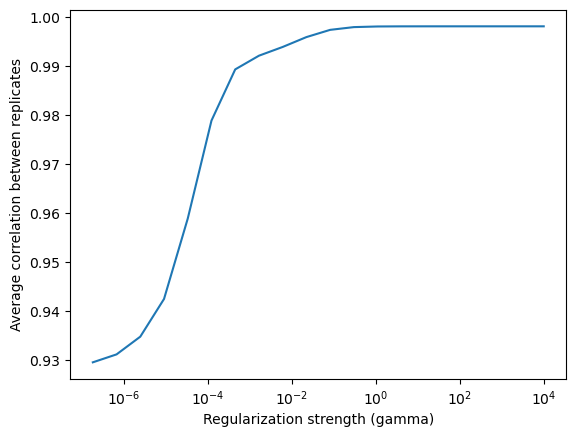

Found best regularization strength gamma = 4.5e-04, R = 0.99
CPU times: user 32.4 s, sys: 1.86 s, total: 34.2 s
Wall time: 31.3 s


In [6]:
%%time

reload(popDMS)

name = 'YAP1'
n_replicates = 2

count_data = dict(
    name = name,
    reference_sequence_file = os.path.join(RAW_DIR, 'YAP1_reference_sequence.dat'),
    haplotype_counts_file = os.path.join(RAW_DIR, 'YAP1_aa2codon_counts.csv.gz'), 
    freq_dir = FREQ_DIR,
    n_replicates = n_replicates,
    time_points = [0, 1, 2, 3],
    time_cols = {1: ['101208_c_0', '101208_c_1', '101208_c_2', '101208_c_3'],  
                 2: ['110307_c_0', '110307_c_1', '110307_c_2', '110307_c_3']},
    comment_char = None
)
popDMS.compute_variant_frequencies(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    with_epistasis = False,
    plot_gamma = True
)
popDMS.infer_correlated(**selection_data)

# TpoR MPL

TpoR replicate 1 complete                                                       
TpoR replicate 2 complete                                                       
TpoR replicate 3 complete                                                       
TpoR replicate 4 complete                                                       
TpoR replicate 5 complete                                                       
TpoR replicate 6 complete                                                       


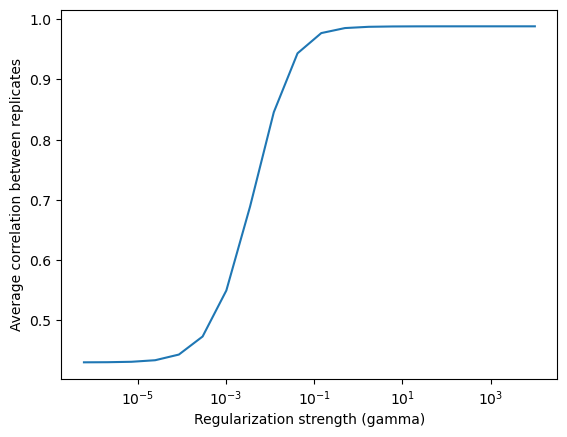

Found best regularization strength gamma = 1.4e-01, R = 0.98
CPU times: user 29.1 s, sys: 4.13 s, total: 33.2 s
Wall time: 26.3 s


In [7]:
%%time

name = 'TpoR'
n_replicates = 6

count_data = dict(
    name = name,
    reference_sequence_file = os.path.join(RAW_DIR, 'TpoR_reference_sequence.dat'),
    haplotype_counts_file = os.path.join(RAW_DIR, 'TpoR_nucleotide_counts.csv'), 
    freq_dir = FREQ_DIR,
    n_replicates = n_replicates,
    time_points = [0, 1],
    time_cols = {1: ['Replicate_A_c_0', 'Replicate_A_c_1'],
                 2: ['Replicate_B_c_0', 'Replicate_B_c_1'],
                 3: ['Replicate_C_c_0', 'Replicate_C_c_1'],
                 4: ['Replicate_D_c_0', 'Replicate_D_c_1'],
                 5: ['Replicate_E_c_0', 'Replicate_E_c_1'],
                 6: ['Replicate_F_c_0', 'Replicate_F_c_1']},
    comment_char = '#'
)
popDMS.compute_variant_frequencies(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    with_epistasis = False,
    plot_gamma = True
)
popDMS.infer_correlated(**selection_data)

# TpoR MPL S505N

TpoR_S505N replicate 1 complete                                                 
TpoR_S505N replicate 2 complete                                                 
TpoR_S505N replicate 3 complete                                                 
TpoR_S505N replicate 4 complete                                                 
TpoR_S505N replicate 5 complete                                                 
TpoR_S505N replicate 6 complete                                                 


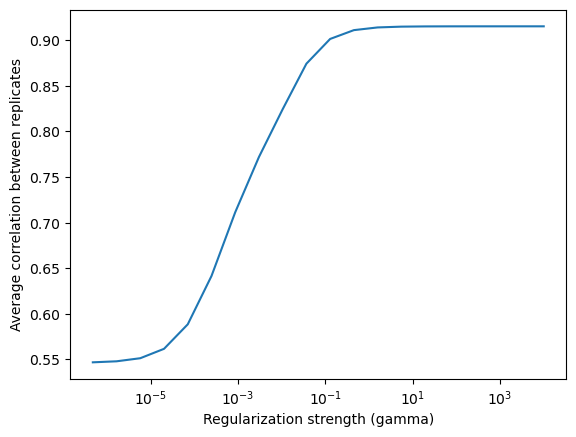

Found best regularization strength gamma = 1.3e-01, R = 0.90
CPU times: user 28.8 s, sys: 4.12 s, total: 33 s
Wall time: 26 s


In [8]:
%%time

reload(popDMS)

name = 'TpoR_S505N'
n_replicates = 6

count_data = dict(
    name = name,
    reference_sequence_file = os.path.join(RAW_DIR, 'TpoR_reference_sequence.dat'),
    haplotype_counts_file = os.path.join(RAW_DIR, 'TpoR_S505N_nucleotide_counts.csv'), 
    freq_dir = FREQ_DIR,
    n_replicates = n_replicates,
    time_points = [0, 1],
    time_cols = {1: ['Replicate_1_c_0', 'Replicate_1_c_1'],
                 2: ['Replicate_2_c_0', 'Replicate_2_c_1'],
                 3: ['Replicate_3_c_0', 'Replicate_3_c_1'],
                 4: ['Replicate_4_c_0', 'Replicate_4_c_1'],
                 5: ['Replicate_5_c_0', 'Replicate_5_c_1'],
                 6: ['Replicate_6_c_0', 'Replicate_6_c_1']},
    comment_char = '#'
)
popDMS.compute_variant_frequencies(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    with_epistasis = False,
    plot_gamma = True
)
popDMS.infer_correlated(**selection_data)

# Ube4b

Ube4b replicate 1 complete                                                      
Ube4b replicate 2 complete                                                      


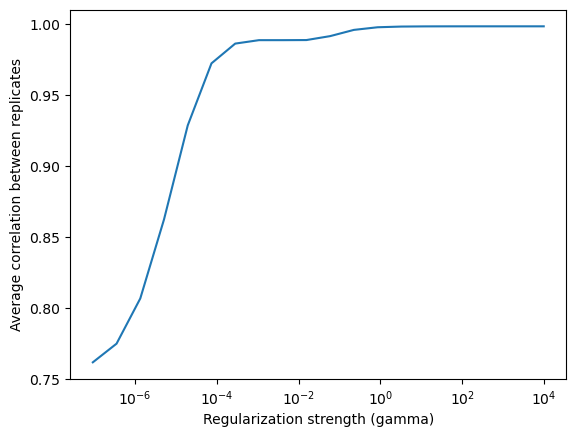

Found best regularization strength gamma = 2.8e-04, R = 0.99
CPU times: user 4min 59s, sys: 6.61 s, total: 5min 6s
Wall time: 4min 31s


In [9]:
%%time

name = 'Ube4b'
n_replicates = 2

count_data = dict(
    name = name,
    reference_sequence_file = os.path.join(RAW_DIR, 'Ube4b_reference_sequence.dat'),
    haplotype_counts_file = os.path.join(RAW_DIR, 'Ube4b_nucleotide_counts.csv'), 
    freq_dir = FREQ_DIR,
    n_replicates = n_replicates,
    time_points = [0, 1, 2, 3],
    time_cols = {1: ['Rep_2_c_0', 'Rep_2_c_1', 'Rep_2_c_2', 'Rep_2_c_3'],
                 2: ['Rep_3_c_0', 'Rep_3_c_1', 'Rep_3_c_2', 'Rep_3_c_3']},
    comment_char = '#'
)
popDMS.compute_variant_frequencies(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    with_epistasis = False,
    plot_gamma = True
)
popDMS.infer_correlated(**selection_data)

# BRCA1

Y2H_1 replicate 1 complete                                                      
Y2H_1 replicate 2 complete                                                      
Y2H_1 replicate 3 complete                                                      


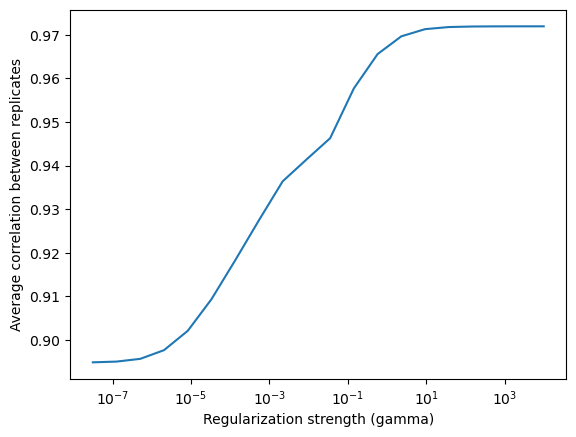

Found best regularization strength gamma = 5.8e-01, R = 0.97
CPU times: user 1h 1min 35s, sys: 35.1 s, total: 1h 2min 10s
Wall time: 43min 55s


In [10]:
%%time

reload(popDMS)

name = 'Y2H_1'
n_replicates = 3

count_data = dict(
    name = name,
    reference_sequence_file = os.path.join(RAW_DIR, 'BRCA1_reference_sequence.dat'),
    haplotype_counts_file = os.path.join(RAW_DIR, 'BRCA1_nucleotide_counts.csv'), 
    freq_dir = FREQ_DIR,
    n_replicates = n_replicates,
    time_points = [0, 18, 37, 45],
    time_cols = {1: ['Y2H_1_Rep1_c_0', 'Y2H_1_Rep1_c_18', 'Y2H_1_Rep1_c_37', 'Y2H_1_Rep1_c_45'],
                 2: ['Y2H_1_Rep2_c_0', 'Y2H_1_Rep2_c_18', 'Y2H_1_Rep2_c_37', 'Y2H_1_Rep2_c_45'],
                 3: ['Y2H_1_Rep3_c_0', 'Y2H_1_Rep3_c_18', 'Y2H_1_Rep3_c_37', 'Y2H_1_Rep3_c_45']},
    comment_char = '#'
)
popDMS.compute_variant_frequencies(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    with_epistasis = False,
    plot_gamma = True
)
popDMS.infer_correlated(**selection_data)

Y2H_2 replicate 1 complete                                                      
Y2H_2 replicate 2 complete                                                      
Y2H_2 replicate 3 complete                                                      


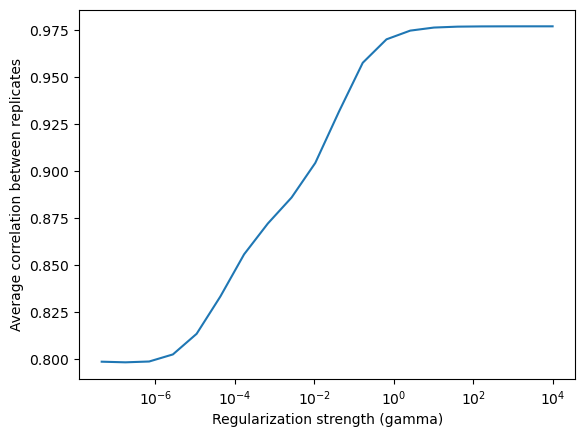

Found best regularization strength gamma = 6.6e-01, R = 0.97
CPU times: user 58min 53s, sys: 34.7 s, total: 59min 27s
Wall time: 41min 11s


In [11]:
%%time

reload(popDMS)

name = 'Y2H_2'
n_replicates = 3

count_data = dict(
    name = name,
    reference_sequence_file = os.path.join(RAW_DIR, 'BRCA1_reference_sequence.dat'),
    haplotype_counts_file = os.path.join(RAW_DIR, 'BRCA1_nucleotide_counts.csv'), 
    freq_dir = FREQ_DIR,
    n_replicates = n_replicates,
    time_points = [0, 16, 41, 64],
    time_cols = {1: ['Y2H_2_Rep1_c_0', 'Y2H_2_Rep1_c_16', 'Y2H_2_Rep1_c_41', 'Y2H_2_Rep1_c_64'],
                 2: ['Y2H_2_Rep2_c_0', 'Y2H_2_Rep2_c_16', 'Y2H_2_Rep2_c_41', 'Y2H_2_Rep2_c_64'],
                 3: ['Y2H_2_Rep3_c_0', 'Y2H_2_Rep3_c_16', 'Y2H_2_Rep3_c_41', 'Y2H_2_Rep3_c_64']},
    comment_char = '#'
)
popDMS.compute_variant_frequencies(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    with_epistasis = False,
    plot_gamma = True
)
popDMS.infer_correlated(**selection_data)

E3 replicate 1 complete                                                         
E3 replicate 2 complete                                                         
E3 replicate 3 complete                                                         
E3 replicate 4 complete                                                         
E3 replicate 5 complete                                                         
E3 replicate 6 complete                                                         


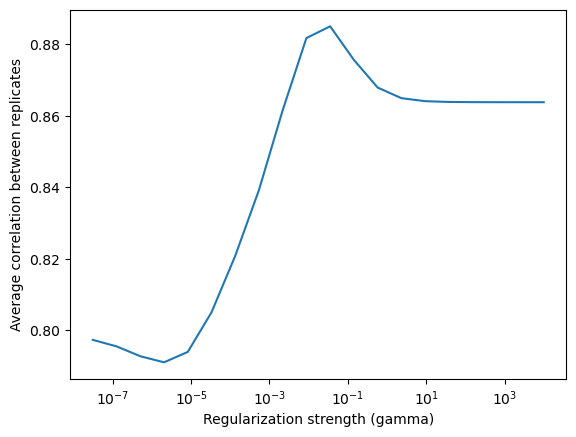

Found best regularization strength gamma = 8.8e-03, R = 0.88
CPU times: user 2h 37min 39s, sys: 1min 19s, total: 2h 38min 59s
Wall time: 2h 2min 57s


In [12]:
%%time

reload(popDMS)

name = 'E3'
n_replicates = 6

count_data = dict(
    name = name,
    reference_sequence_file = os.path.join(RAW_DIR, 'BRCA1_reference_sequence.dat'),
    haplotype_counts_file = os.path.join(RAW_DIR, 'BRCA1_nucleotide_counts.csv'), 
    freq_dir = FREQ_DIR,
    n_replicates = n_replicates,
    time_points = [0, 1, 2, 3, 4, 5],
    time_cols = {1: ['PlusE2NewRep3_c_0', 'PlusE2NewRep3_c_1', 'PlusE2NewRep3_c_2', 'PlusE2NewRep3_c_3', 'PlusE2NewRep3_c_4', 
                     'PlusE2NewRep3_c_5'],
                 2: ['PlusE2NewRep4_c_0', 'PlusE2NewRep4_c_1', 'PlusE2NewRep4_c_2', 'PlusE2NewRep4_c_3', 'PlusE2NewRep4_c_4', 
                     'PlusE2NewRep4_c_5'],
                 3: ['PlusE2NewRep5_c_0', 'PlusE2NewRep5_c_1', 'PlusE2NewRep5_c_2', 'PlusE2NewRep5_c_3', 'PlusE2NewRep5_c_4', 
                     'PlusE2NewRep5_c_5'],
                 4: ['PlusE2Rep3_c_0', 'PlusE2Rep3_c_1', 'PlusE2Rep3_c_2', 'PlusE2Rep3_c_3', 'PlusE2Rep3_c_4', 'PlusE2Rep3_c_5'],
                 5: ['PlusE2Rep4_c_0', 'PlusE2Rep4_c_1', 'PlusE2Rep4_c_2', 'PlusE2Rep4_c_3', 'PlusE2Rep4_c_4', 'PlusE2Rep4_c_5'],
                 6: ['PlusE2Rep5_c_0', 'PlusE2Rep5_c_1', 'PlusE2Rep5_c_2', 'PlusE2Rep5_c_3', 'PlusE2Rep5_c_4', 'PlusE2Rep5_c_5']},
    comment_char = '#'
)
popDMS.compute_variant_frequencies(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    with_epistasis = False,
    plot_gamma = True
)
popDMS.infer_correlated(**selection_data)

# DBR1

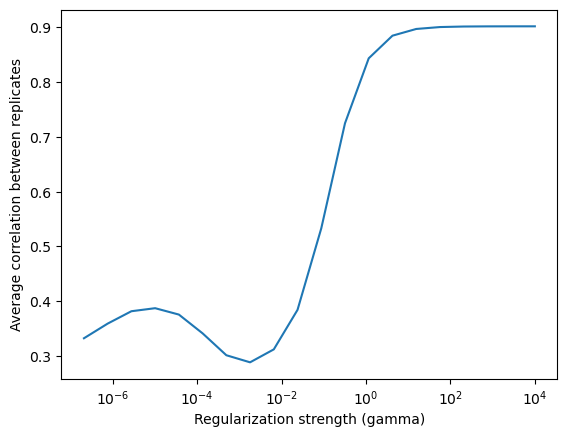

Found best regularization strength gamma = 4.2e+00, R = 0.88
CPU times: user 20min 52s, sys: 2.74 s, total: 20min 55s
Wall time: 20min 54s


In [13]:
%%time

reload(popDMS)

name = 'DBR1'
n_replicates = 2

count_data = dict(
    dir = FREQ_DIR,
    name = name,
    types = ['single', 'double'],
    n_replicates = n_replicates,
    reference_sequence_file = os.path.join(RAW_DIR, name + '_reference_sequence.dat'),
    comment_char = None
)
popDMS.convert_codon_counts_to_variant_frequencies(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    with_epistasis = False,
    plot_gamma = True
)
popDMS.infer_correlated(**selection_data)

# SARS-CoV-2 Spike

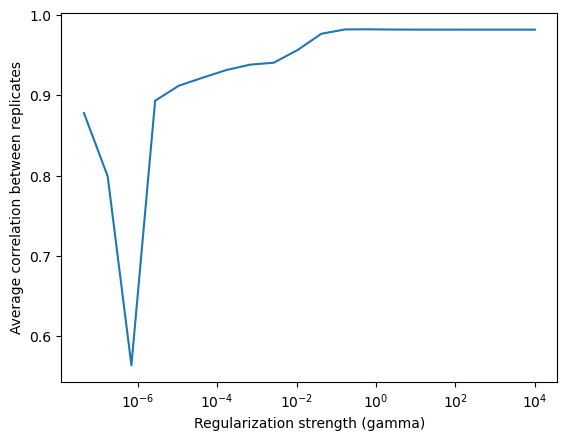

Found best regularization strength gamma = 4.2e-02, R = 0.98
CPU times: user 9min 16s, sys: 7.95 s, total: 9min 23s
Wall time: 5min 37s


In [14]:
%%time

reload(popDMS)

name = 'Spike'
n_replicates = 2

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_correlated(**selection_data)

# Independent (no mutant-mutant correlations) proteins

# Zika virus

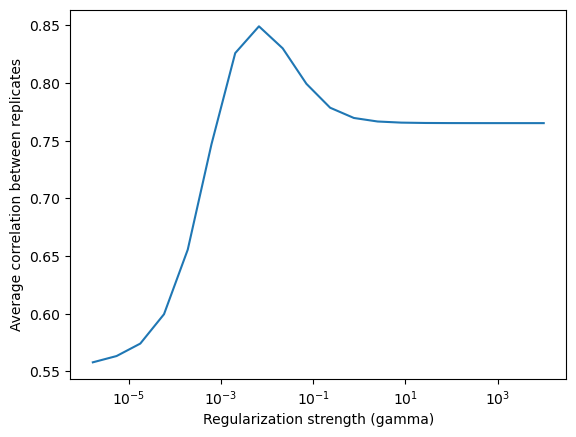

Found best regularization strength gamma = 6.7e-03, R = 0.85
CPU times: user 9.91 s, sys: 96.6 ms, total: 10 s
Wall time: 9.98 s


In [15]:
%%time

reload(popDMS)

name = 'ZIKV'
n_replicates = 3

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % name),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# Influenza Perth 2009 (H3N2)

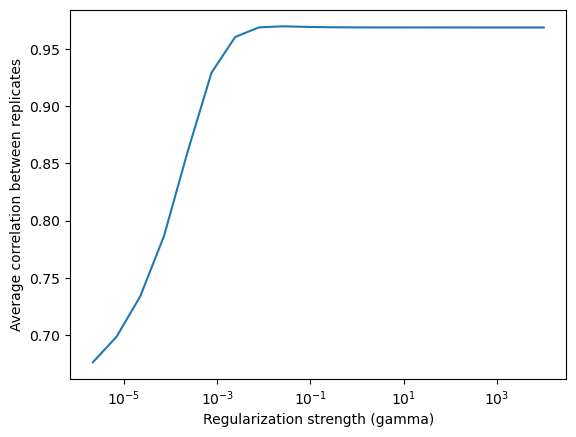

Found best regularization strength gamma = 2.4e-03, R = 0.96
CPU times: user 14.5 s, sys: 169 ms, total: 14.7 s
Wall time: 14.7 s


In [16]:
%%time

reload(popDMS)

name = 'Perth2009'
n_replicates = 4

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % name),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# Influenza WSN

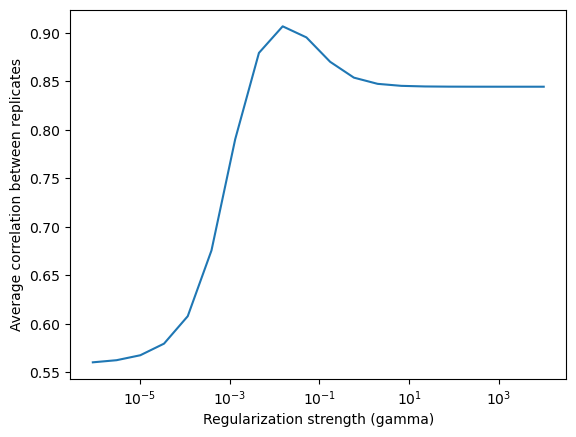

Found best regularization strength gamma = 1.5e-02, R = 0.91
CPU times: user 10.9 s, sys: 87.6 ms, total: 11 s
Wall time: 10.9 s


In [17]:
%%time

reload(popDMS)

name = 'WSN'
n_replicates = 3

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % name),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# Influenza PR8

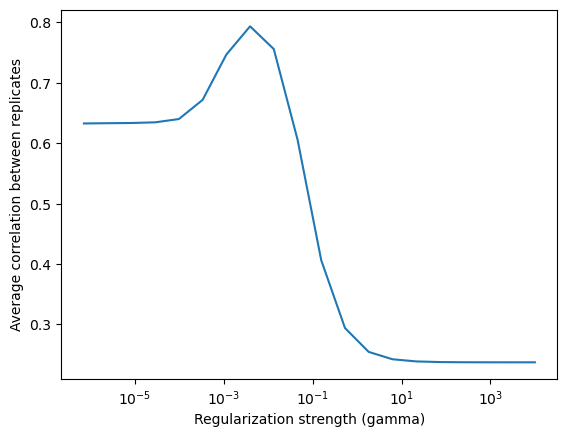

Found best regularization strength gamma = 3.9e-03, R = 0.79
CPU times: user 9.5 s, sys: 90 ms, total: 9.59 s
Wall time: 9.56 s


In [18]:
%%time

reload(popDMS)

name = 'PR8'
n_replicates = 3

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % name),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# Influenza Aichi 68C

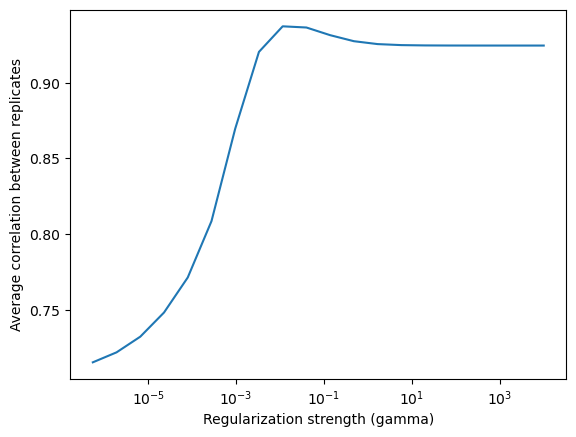

Found best regularization strength gamma = 1.2e-02, R = 0.94
CPU times: user 6.5 s, sys: 46.9 ms, total: 6.54 s
Wall time: 6.54 s


In [19]:
%%time

reload(popDMS)

name = 'Aichi68C'
n_replicates = 2

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % name),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# Influenza Matrix_M1

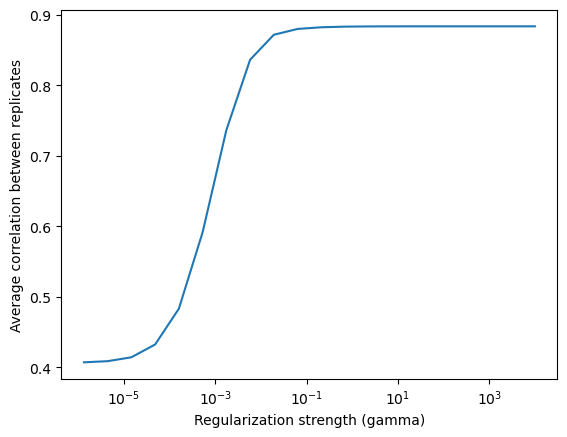

Found best regularization strength gamma = 1.9e-02, R = 0.87
CPU times: user 4.98 s, sys: 32.1 ms, total: 5.01 s
Wall time: 5.02 s


In [20]:
%%time

reload(popDMS)

name = 'Matrix_M1'
filename = 'HomM1'
n_replicates = 3

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % filename),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# Influenza A549

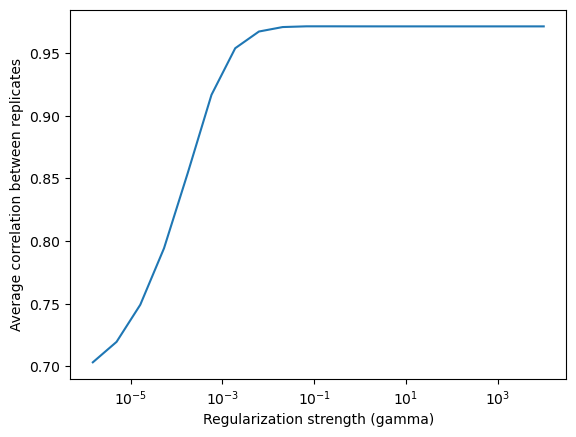

Found best regularization strength gamma = 6.3e-03, R = 0.97
CPU times: user 14.7 s, sys: 103 ms, total: 14.8 s
Wall time: 14.8 s


In [21]:
%%time

reload(popDMS)

name = 'A549'
n_replicates = 3

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % name),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# Influenza CCL141

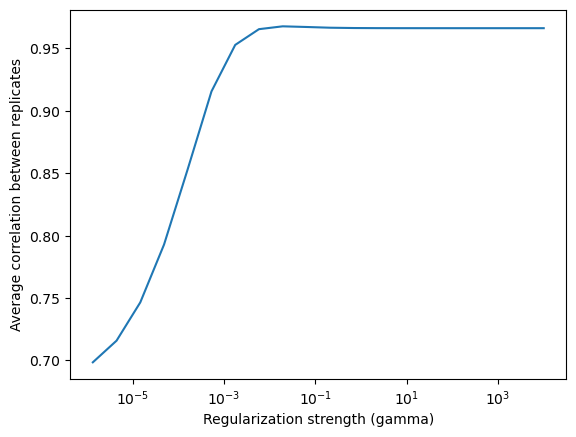

Found best regularization strength gamma = 5.8e-03, R = 0.97
CPU times: user 14.7 s, sys: 96.2 ms, total: 14.8 s
Wall time: 14.7 s


In [22]:
%%time

reload(popDMS)

name = 'CCL141'
n_replicates = 3

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % name),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# Influenza MS

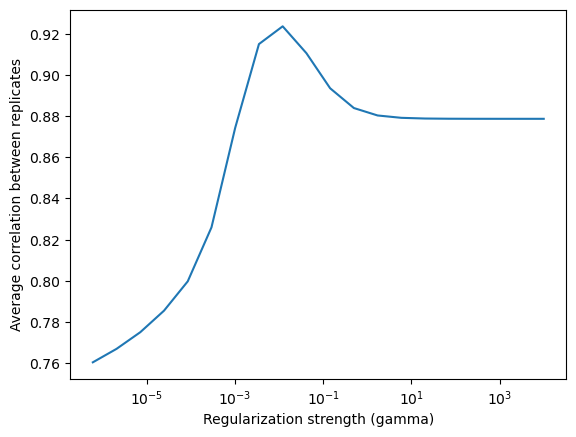

Found best regularization strength gamma = 1.2e-02, R = 0.92
CPU times: user 6.52 s, sys: 56.8 ms, total: 6.58 s
Wall time: 6.56 s


In [23]:
%%time

reload(popDMS)

name = 'MS'
n_replicates = 2

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % name),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# Influenza MxA

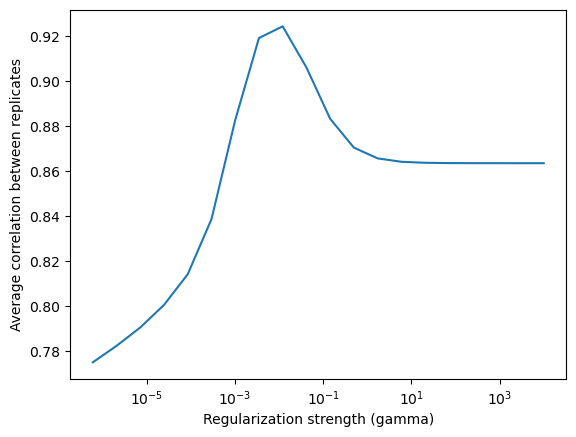

Found best regularization strength gamma = 3.5e-03, R = 0.92
CPU times: user 6.5 s, sys: 57.5 ms, total: 6.56 s
Wall time: 6.54 s


In [24]:
%%time

reload(popDMS)

name = 'MxA'
n_replicates = 2

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % name),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# Influenza MxAneg

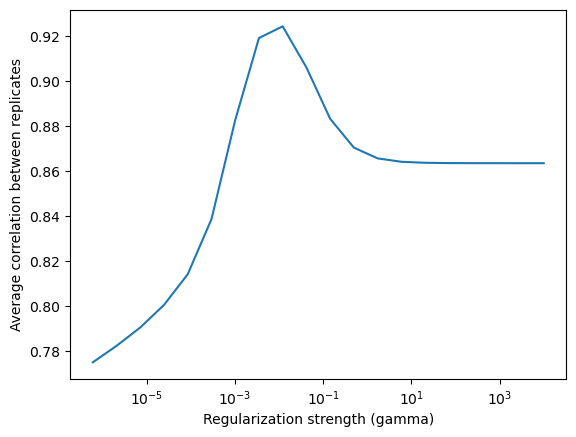

Found best regularization strength gamma = 3.5e-03, R = 0.92
CPU times: user 6.51 s, sys: 83.9 ms, total: 6.59 s
Wall time: 6.58 s


In [25]:
%%time

reload(popDMS)

name = 'MxAneg'
n_replicates = 2

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (name, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % name),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# Influenza H3N2 NA

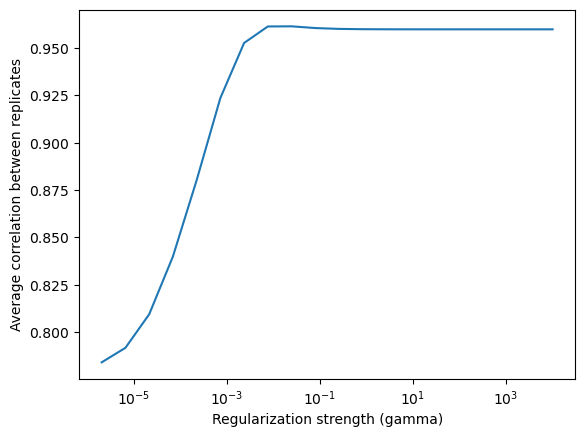

Found best regularization strength gamma = 7.6e-03, R = 0.96
CPU times: user 1.15 s, sys: 12 ms, total: 1.16 s
Wall time: 1.16 s


In [26]:
%%time

reload(popDMS)

name = 'H3N2 NA'
n_replicates = 2

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# HIV Env BG505

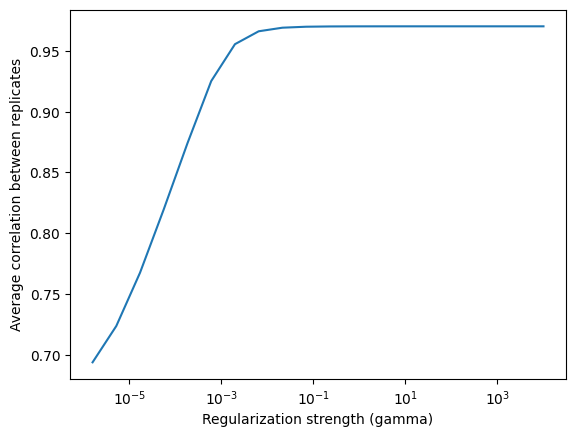

Found best regularization strength gamma = 2.0e-03, R = 0.96
CPU times: user 51.5 s, sys: 177 ms, total: 51.7 s
Wall time: 52.9 s


In [2]:
%%time

reload(paperPop)

name = 'HIV Env BG505'
filename = 'BG505'
n_replicates = 3

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % filename),
    comment_char = None
)
paperPop.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
paperPop.infer_independent(**selection_data)

# HIV Env BF520

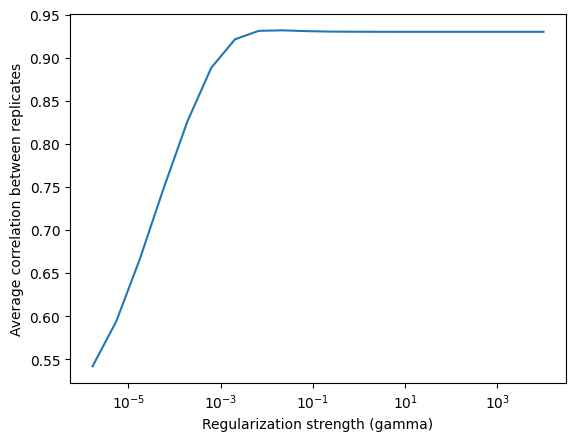

Found best regularization strength gamma = 2.0e-03, R = 0.92


TypeError: 'NoneType' object is not subscriptable

In [3]:
%%time

reload(paperPop)

name = 'HIV Env BF520'
filename = 'BF520'
n_replicates = 3

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % filename),
    comment_char = None
)
paperPop.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
aa_freqs = paperPop.infer_independent(**selection_data)
test = aa_freqs["single"]

In [4]:
print(test[0])

       generation  site aa  frequency  WT_indicator
0               0    30  A   0.999249          True
1               0    30  R   0.000000         False
2               0    30  N   0.000000         False
3               0    30  D   0.000000         False
4               0    30  C   0.000000         False
...           ...   ... ..        ...           ...
27799           1   691  T   0.000111         False
27800           1   691  W   0.000022         False
27801           1   691  Y   0.000056         False
27802           1   691  V   0.000119         False
27803           1   691  *   0.000015         False

[27804 rows x 5 columns]


# HIV Env BF520 human host

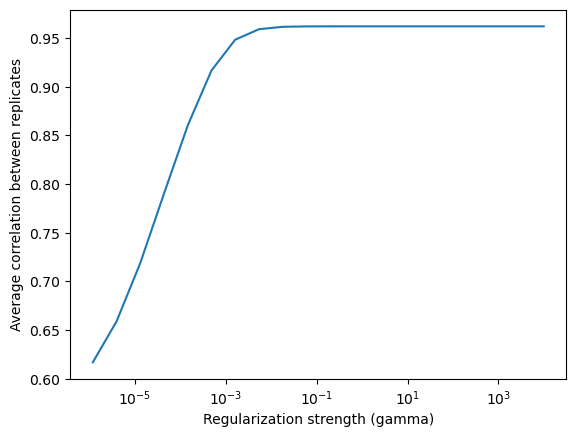

Found best regularization strength gamma = 1.6e-03, R = 0.95
CPU times: user 8.7 s, sys: 92.9 ms, total: 8.79 s
Wall time: 8.78 s


In [29]:
%%time

reload(popDMS)

name = 'HIV BF520 human'
filename = 'human'
n_replicates = 2

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % filename),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# HIV Env BF520 rhesus host

dx shape: (2, 670, 21)
icov shape: (2, 670, 21, 21)
icov thingy shape:  (21, 21)
dx thingy shape:  (21,)
temp shape: (21,)
icov thingy shape:  (21, 21)
dx thingy shape:  (21,)
temp shape: (21,)
icov thingy shape:  (21, 21)
dx thingy shape:  (21,)
temp shape: (21,)
icov thingy shape:  (21, 21)
dx thingy shape:  (21,)
temp shape: (21,)
icov thingy shape:  (21, 21)
dx thingy shape:  (21,)
temp shape: (21,)
icov thingy shape:  (21, 21)
dx thingy shape:  (21,)
temp shape: (21,)
icov thingy shape:  (21, 21)
dx thingy shape:  (21,)
temp shape: (21,)
icov thingy shape:  (21, 21)
dx thingy shape:  (21,)
temp shape: (21,)
icov thingy shape:  (21, 21)
dx thingy shape:  (21,)
temp shape: (21,)
icov thingy shape:  (21, 21)
dx thingy shape:  (21,)
temp shape: (21,)
icov thingy shape:  (21, 21)
dx thingy shape:  (21,)
temp shape: (21,)
icov thingy shape:  (21, 21)
dx thingy shape:  (21,)
temp shape: (21,)
icov thingy shape:  (21, 21)
dx thingy shape:  (21,)
temp shape: (21,)
icov thingy shape:  (21, 

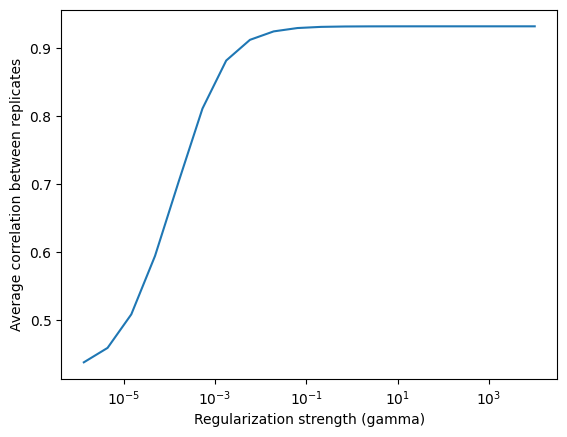

Found best regularization strength gamma = 5.8e-03, R = 0.91
CPU times: user 8.54 s, sys: 68.1 ms, total: 8.61 s
Wall time: 8.7 s


{'single': [       generation  site aa  frequency  WT_indicator
  0               0    30  A   0.999230          True
  1               0    30  R   0.000000         False
  2               0    30  N   0.000000         False
  3               0    30  D   0.000000         False
  4               0    30  C   0.000000         False
  ...           ...   ... ..        ...           ...
  28135           1   699  T   0.000000         False
  28136           1   699  W   0.000000         False
  28137           1   699  Y   0.000000         False
  28138           1   699  V   0.000000         False
  28139           1   699  *   0.000339         False
  
  [28140 rows x 5 columns],
         generation  site aa  frequency  WT_indicator
  0               0    30  A   0.999133          True
  1               0    30  R   0.000000         False
  2               0    30  N   0.000000         False
  3               0    30  D   0.000000         False
  4               0    30  C   0.000000  

In [2]:
%%time

reload(popDMS)

name = 'HIV BF520 rhesus'
filename = 'rhesus'
n_replicates = 2

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % filename),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# HIV bnAbs FP16

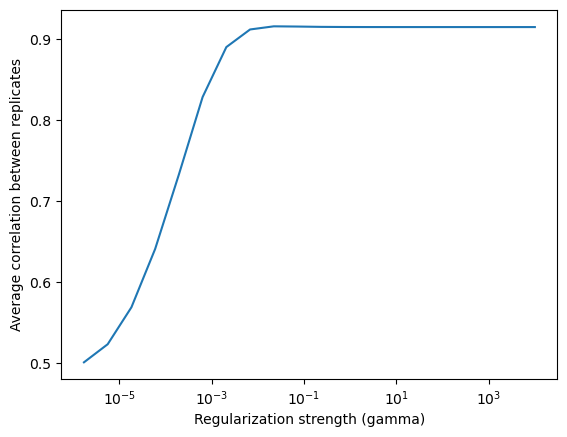

Found best regularization strength gamma = 6.8e-03, R = 0.91
CPU times: user 8.66 s, sys: 79.4 ms, total: 8.74 s
Wall time: 8.72 s


In [31]:
%%time

reload(popDMS)

name = 'HIV bnAbs FP16'
filename = 'FP16'
n_replicates = 2

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % filename),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# HIV bnAbs FP20

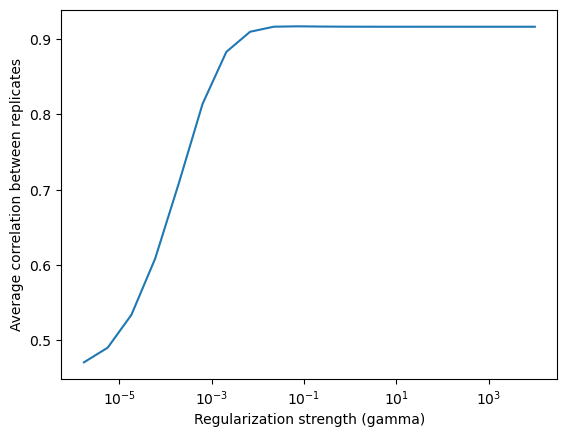

Found best regularization strength gamma = 6.8e-03, R = 0.91
CPU times: user 8.77 s, sys: 77.6 ms, total: 8.85 s
Wall time: 8.84 s


In [32]:
%%time

reload(popDMS)

name = 'HIV bnAbs FP20'
filename = 'FP20'
n_replicates = 2

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % filename),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# HIV bnAbs VRC34

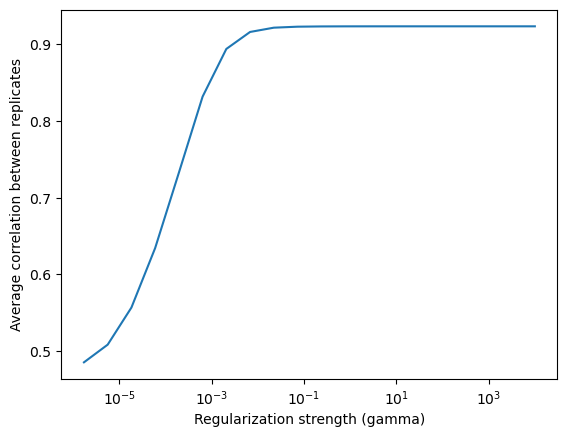

Found best regularization strength gamma = 6.8e-03, R = 0.92
CPU times: user 8.64 s, sys: 67.1 ms, total: 8.71 s
Wall time: 8.69 s


In [33]:
%%time

reload(popDMS)

name = 'HIV bnAbs VRC34'
filename = 'VRC34'
n_replicates = 2

count_data = dict(
    name = name,
    codon_counts_files = [os.path.join(RAW_DIR, '%s_mutDNA-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)] + \
                         [os.path.join(RAW_DIR, '%s_mutvirus-%d_codoncounts.csv' % (filename, i+1)) for i in range(n_replicates)],
    replicates = [i+1 for i in range(n_replicates)] + [i+1 for i in range(n_replicates)],
    times = [0 for i in range(n_replicates)] + [1 for i in range(n_replicates)],
    freq_dir = FREQ_DIR,
    # error_file = os.path.join(RAW_DIR, '%s_DNA_codoncounts.csv' % filename),
    comment_char = None
)
popDMS.compute_variant_frequencies_Bloom(**count_data)

selection_data = dict(
    name = name,
    freq_dir = FREQ_DIR,
    output_dir = SEL_DIR,
    n_replicates = n_replicates,
    corr_cutoff_pct = CORR_CUTOFF_PCT,
    # gamma = CONST_GAMMA,
    norm_WT = False,
    plot_gamma = True
)
popDMS.infer_independent(**selection_data)

# Comparing enrichment ratios and selection coefficients at example sites

In [ ]:
import numpy as np
import pandas as pd

name = 'HIV Env BG505'
filename = 'BG505'
n_replicates = 3
gamma = 2e-3

ex_sites = [        592,        596,         508,         525]
ex_aas   = [['I', 'L',], ['S', 'F'], ['G', 'R', 'Y', 'H', 'F', 'K'], ['S', 'N',]]

df = [pd.read_csv(os.path.join(FREQ_DIR, name + ('_single_aa_rep_%d.csv.gz' % (rep+1)))) for rep in range(n_replicates)]

for i_site in range(len(ex_sites)):
    print('%s site %d' % (name, ex_sites[i_site]))
    print('residue\treplicate\tx0\t\tx1\t\tratio\t\td log\t\td logit\t\traw s\t\treg s')

    for a in ex_aas[i_site]:
        for i_rep in range(n_replicates):
            df_temp = df[i_rep][(df[i_rep]['site']==ex_sites[i_site]) & (df[i_rep]['aa']==a)]
            x0 = df_temp[df_temp['generation']==0].iloc[0]['frequency']
            x1 = df_temp[df_temp['generation']==1].iloc[0]['frequency']
            
            xvar   = ((x0+x1)/2) * (1 - ((x0+x1)/2)) 
            ratio  = x1/x0
            dlog   = np.log(x1/x0)
            dlogit = np.log(x1/(1-x1))-np.log(x0/(1-x0))
            s_raw  = (x1 - x0) / xvar
            s_reg  = (x1 - x0) / (xvar + gamma)

            res_str = a if i_rep==0 else ''
            print('%s\t%d\t\t%.3e\t%.3e\t%.3e\t%.3e\t%.3e\t%.3e\t%.3e' % (res_str, i_rep+1, x0, x1, ratio, dlog, dlogit, s_raw, s_reg))

    print('')

In [ ]:
import numpy as np
import pandas as pd

name = 'Ube4b'
n_replicates = 2
gamma = 2.8e-04

ex_sites = [             34]
ex_aas   = [['A', 'D', 'N']]

df = [pd.read_csv(os.path.join(FREQ_DIR, name + ('_single_aa_rep_%d.csv.gz' % (rep+1)))) for rep in range(n_replicates)]

for i_site in range(len(ex_sites)):
    print('%s site %d' % (name, ex_sites[i_site]))
    print('residue\treplicate\tx0\t\tx1\t\tratio\t\td log\t\td logit\t\traw s\t\treg s')

    for a in ex_aas[i_site]:
        for i_rep in range(n_replicates):
            df_temp = df[i_rep][(df[i_rep]['site']==ex_sites[i_site]) & (df[i_rep]['aa']==a)]
            x = [df_temp[df_temp['generation']==i].iloc[0]['frequency'] for i in range(4)]

            xvar   = [((x[i]+x[i+1])/2) * (1 - ((x[i]+x[i+1])/2)) for i in range(len(x)-1)] 
            ratio  = x[-1]/x[0]
            dlog   = np.log(x[-1]/x[0])
            dlogit = np.log(x[-1]/(1-x[-1]))-np.log(x[0]/(1-x[0]))
            s_raw  = (x[-1] - x[0]) / np.sum(xvar)
            s_reg  = (x[-1] - x[0]) / (np.sum(xvar) + gamma)

            res_str = a if i_rep==0 else ''
            print('%s\t%d\t\t%.3e\t%.3e\t%.3e\t%.3e\t%.3e\t%.3e\t%.3e' % (res_str, i_rep+1, x[0], x[-1], ratio, dlog, dlogit, s_raw, s_reg))

    print('')